# Imports

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from scipy.stats import shapiro, normaltest
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score, log_loss, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay,
    roc_curve, precision_recall_curve
)

from lightgbm import LGBMClassifier

from collections import defaultdict

/home/antonio/projetos/fase-5/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Funções úteis

### verificar_normalidade

In [2]:
def verificar_normalidade(data_series, feature_name, alpha=0.05):
    """
    Aplica os testes de Shapiro-Wilk e D'Agostino's K-squared a uma série de dados
    e imprime uma conclusão sobre sua normalidade.

    Args:
        data_series (pd.Series): A série de dados (coluna do DataFrame) a ser testada.
        feature_name (str): O nome da feature para impressão.
        alpha (float): O nível de significância para o teste.
    """
    print(f"--- Análise de Normalidade para a Feature: '{feature_name}' ---")

    # 1. Teste de Shapiro-Wilk
    stat_shapiro, p_shapiro = shapiro(data_series)
    print(f"\n1. Teste de Shapiro-Wilk:")
    print(f"   - Estatística do teste = {stat_shapiro:.4f}")
    print(f"   - P-valor = {p_shapiro:.4f}")
    if p_shapiro > alpha:
        print(f"   - Conclusão (alpha={alpha}): Não há evidência para rejeitar a normalidade (Normal).")
    else:
        print(f"   - Conclusão (alpha={alpha}): A hipótese de normalidade é rejeitada (Não Normal).")

    # 2. Teste de D'Agostino's K-squared
    stat_k2, p_k2 = normaltest(data_series)
    print(f"\n2. Teste de D'Agostino's K-squared:")
    print(f"   - Estatística do teste = {stat_k2:.4f}")
    print(f"   - P-valor = {p_k2:.4f}")
    if p_k2 > alpha:
        print(f"   - Conclusão (alpha={alpha}): Não há evidência para rejeitar a normalidade (Normal).")
    else:
        print(f"   - Conclusão (alpha={alpha}): A hipótese de normalidade é rejeitada (Não Normal).")

    print("-" * 50 + "\n")

### aplicar_transformacao_log

In [3]:
def aplicar_transformacao_log(df, colunas):
    """
    Aplica a transformação logarítmica (log1p) a uma lista de colunas
    de um DataFrame e cria novas colunas com o sufixo '_log'.

    Args:
        df (pd.DataFrame): O DataFrame de entrada.
        colunas (list): Uma lista de nomes de colunas para transformar.

    Returns:
        pd.DataFrame: O DataFrame com as novas colunas transformadas.
    """
    df_transformado = df.copy()
    #new_columns = []
    for col in colunas:
        # Verifica se a coluna existe no DataFrame
        if col in df_transformado.columns:
            df_transformado[col + '_log'] = np.log1p(df_transformado[col])
            #new_columns.append(col + '_log')
        else:
            print(f"Aviso: A coluna '{col}' não foi encontrada no DataFrame.")

    return df_transformado

### perform_cross_validation

In [4]:
def perform_cross_validation(X_train, y_train, skf, model):
    """
    Realiza validação cruzada estratificada para CLASSIFICAÇÃO BINÁRIA.

    Para cada fold, treina o modelo fornecido com escalonamento de features,
    calcula predições e probabilidades, e retorna um dicionário com as métricas
    de desempenho tanto para o conjunto de treino quanto para o de validação.

    Parameters
    ----------
    X_train : pd.DataFrame or np.ndarray
        Features do conjunto de treinamento.
    y_train : pd.Series or np.ndarray
        Labels do conjunto de treinamento (binários: 0 ou 1).
        Classe positiva (1) representa evasão do aluno.
    skf : StratifiedKFold
        Objeto StratifiedKFold configurado.
    model : estimator object
        Instância do modelo de classificação a ser treinado.

    Returns
    -------
    results : dict
        Dicionário contendo as listas de métricas calculadas para cada fold.
        Estrutura: results[dataset][metric] = [valores por fold]
    """
    
    # Dicionário para armazenar os resultados
    results = defaultdict(lambda: defaultdict(list))
    
    n_splits = skf.get_n_splits()

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        print(f"\n{'='*60}")
        print(f"Processando Fold {fold}/{n_splits}")
        print(f"{'='*60}")

        # Divisão dos dados do fold (usando indexação que funciona para pandas e numpy)
        if isinstance(X_train, pd.DataFrame):
            X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        else:
            X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]

        if isinstance(y_train, pd.Series):
            y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        else:
            y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        # Escalonamento das features
        scaler = StandardScaler()
        
        if isinstance(X_train, pd.DataFrame):
            X_train_fold_scaled = pd.DataFrame(
                scaler.fit_transform(X_train_fold),
                columns=X_train_fold.columns,
                index=X_train_fold.index
            )
            X_val_fold_scaled = pd.DataFrame(
                scaler.transform(X_val_fold),
                columns=X_val_fold.columns,
                index=X_val_fold.index
            )
        else:
            X_train_fold_scaled = scaler.fit_transform(X_train_fold)
            X_val_fold_scaled = scaler.transform(X_val_fold)

        # Treinamento do modelo
        model.fit(X_train_fold_scaled, y_train_fold)

        # Predições e Probabilidades
        datasets = {
            'train': (y_train_fold, X_train_fold_scaled),
            'validation': (y_val_fold, X_val_fold_scaled)
        }

        # Cálculo e Armazenamento das Métricas
        for name, (y_true, X_scaled) in datasets.items():
            # Predições
            y_pred = model.predict(X_scaled)
            y_proba = model.predict_proba(X_scaled)
            
            # Para classificação binária: extrair probabilidade da classe positiva (coluna 1)
            y_proba_pos = y_proba[:, 1]

            # Calculando as métricas para classificação binária
            acc = accuracy_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred, pos_label=1)
            recall = recall_score(y_true, y_pred, pos_label=1)
            precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
            loss = log_loss(y_true, y_proba)  # Log loss (menor é melhor)
            roc = roc_auc_score(y_true, y_proba_pos)  # ROC-AUC binário
            pr_auc = average_precision_score(y_true, y_proba_pos)  # PR-AUC binário

            # Armazenando os resultados
            results[name]['accuracy'].append(acc)
            results[name]['f1_score'].append(f1)
            results[name]['recall'].append(recall)
            results[name]['precision'].append(precision)
            results[name]['log_loss'].append(loss)
            results[name]['roc_auc'].append(roc)
            results[name]['pr_auc'].append(pr_auc)
        
        # Exibir métricas do fold atual
        print(f"\nTrain      - Acc: {results['train']['accuracy'][-1]:.4f} | "
              f"F1: {results['train']['f1_score'][-1]:.4f} | "
              f"ROC-AUC: {results['train']['roc_auc'][-1]:.4f}")
        print(f"Validation - Acc: {results['validation']['accuracy'][-1]:.4f} | "
              f"F1: {results['validation']['f1_score'][-1]:.4f} | "
              f"ROC-AUC: {results['validation']['roc_auc'][-1]:.4f}")

    print(f"\n{'='*60}")
    print("✅ Validação Cruzada concluída!")
    print(f"{'='*60}")
    
    return dict(results)

### analise_nulos

In [5]:
def analise_nulos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Gera um relatório contendo a quantidade e a porcentagem de valores nulos por coluna.

    Args:
        df (pd.DataFrame): O DataFrame a ser analisado.

    Returns:
        pd.DataFrame: Um DataFrame contendo as colunas 'nome_coluna', 'qtd_nulos' 
                      e 'porcentagem_nulos', ordenado decrescentemente pela quantidade de nulos.
    """
    # Cálculo das métricas
    nulos = df.isnull().sum()
    porcentagem = ((nulos / len(df)) * 100).round(2)
    
    # Criação do DataFrame de resumo
    df_nulos = pd.DataFrame({
        'qtd_nulos': nulos,
        'porcentagem_nulos': porcentagem
    })
    
    # Ajuste do índice para se tornar uma coluna
    df_nulos.reset_index(inplace=True)
    df_nulos.rename(columns={'index': 'nome_coluna'}, inplace=True)
    
    # Ordenação
    df_nulos.sort_values(by='qtd_nulos', ascending=False, inplace=True)
    
    return df_nulos

# Loading data

In [6]:
data_dir = '../data/processed'

file_name_concatenado = 'df_model_concatenado.csv'
file_path_concatenado = os.path.join(data_dir, file_name_concatenado)

df_loaded = pd.read_csv(file_path_concatenado)
df_loaded.head()

,ra,fase_atual,turma_atual,nivel_de_defasagem,fase_ideal,idade,genero,ano_de_ingresso,instituicao_ensino,veterano,em_fase,qtde_aval_realizadas,iaa,ieg,ips,ida,ipv,ian,evadiu
0,RA-1,Fase 7,A,-1.0,Fase 8,19.0,1.0,2016.0,Pública,1.0,0.0,4.0,8.3,4.1,5.6,4.0,7.278,5.0,0.0
1,RA-10,Fase 7,A,-1.0,Fase 8,18.0,1.0,2021.0,Pública,1.0,0.0,4.0,8.3,5.2,5.0,4.1,7.056,5.0,1.0
2,RA-100,Fase 4,A,1.0,Fase 3,13.0,1.0,2019.0,Privada,1.0,0.0,4.0,8.8,7.8,5.0,7.6,7.250,10.0,1.0
3,RA-101,Fase 4,A,-1.0,Fase 5,15.0,1.0,2021.0,Pública,1.0,0.0,4.0,7.9,8.3,7.5,7.6,6.833,5.0,1.0
4,RA-102,Fase 4,A,0.0,Fase 4,14.0,0.0,2019.0,Pública,1.0,1.0,4.0,6.7,7.7,6.9,5.7,6.000,10.0,1.0


In [7]:
analise_nulos(df_loaded)

,nome_coluna,qtd_nulos,porcentagem_nulos
0,ra,0,0.0
1,fase_atual,0,0.0
2,turma_atual,0,0.0
3,nivel_de_defasagem,0,0.0
4,fase_ideal,0,0.0
5,idade,0,0.0
6,genero,0,0.0
7,ano_de_ingresso,0,0.0
8,instituicao_ensino,0,0.0
9,veterano,0,0.0


## numerical and categorical features

In [8]:
target = df_loaded[['evadiu']].astype('int64')
num_features = df_loaded.select_dtypes(['float64','int64']).drop(columns=['evadiu']).columns.tolist()
categorical_features = df_loaded.select_dtypes(['object','category','str']).columns.tolist()

In [9]:
df_loaded[num_features].head()

,nivel_de_defasagem,idade,genero,ano_de_ingresso,veterano,em_fase,qtde_aval_realizadas,iaa,ieg,ips,ida,ipv,ian
0,-1.0,19.0,1.0,2016.0,1.0,0.0,4.0,8.3,4.1,5.6,4.0,7.278,5.0
1,-1.0,18.0,1.0,2021.0,1.0,0.0,4.0,8.3,5.2,5.0,4.1,7.056,5.0
2,1.0,13.0,1.0,2019.0,1.0,0.0,4.0,8.8,7.8,5.0,7.6,7.250,10.0
3,-1.0,15.0,1.0,2021.0,1.0,0.0,4.0,7.9,8.3,7.5,7.6,6.833,5.0
4,0.0,14.0,0.0,2019.0,1.0,1.0,4.0,6.7,7.7,6.9,5.7,6.000,10.0


In [10]:
df_loaded[categorical_features].head()

,ra,fase_atual,turma_atual,fase_ideal,instituicao_ensino
0,RA-1,Fase 7,A,Fase 8,Pública
1,RA-10,Fase 7,A,Fase 8,Pública
2,RA-100,Fase 4,A,Fase 3,Privada
3,RA-101,Fase 4,A,Fase 5,Pública
4,RA-102,Fase 4,A,Fase 4,Pública


In [11]:
df_loaded[categorical_features]['fase_atual'].value_counts()

fase_atual
Fase 0    421
Fase 1    365
Fase 2    354
Fase 3    280
Fase 4    163
Fase 5    124
Fase 6     49
Fase 7     27
Name: count, dtype: int64

In [12]:
df_loaded[categorical_features]['fase_ideal'].value_counts()

fase_ideal
Fase 2    464
Fase 3    410
Fase 1    204
Fase 0    187
Fase 4    179
Fase 5    121
Fase 6    101
Fase 7     88
Fase 8     29
Name: count, dtype: int64

In [13]:
df_loaded[categorical_features]['instituicao_ensino'].value_counts()

instituicao_ensino
Pública    1554
Privada     229
Name: count, dtype: int64

In [14]:
df_loaded[categorical_features]['turma_atual'].value_counts()

turma_atual
A    209
L    169
B    145
F    134
M    121
K    119
G    100
D     90
C     89
N     84
P     70
J     64
U     62
H     60
R     54
I     42
E     35
Q     34
O     25
S     19
T     17
V     16
Y     16
Z      9
Name: count, dtype: int64

# Tratamento de dados inicial

## Feature 'instituicao_ensino'

In [15]:
map_instituicao = {'Pública' : 1,
                   'Privada': 0}
df_loaded['instituicao_ensino_mapped'] = df_loaded['instituicao_ensino'].map(map_instituicao)
df_loaded['instituicao_ensino_mapped'].value_counts()


instituicao_ensino_mapped
1    1554
0     229
Name: count, dtype: int64

## Separação dos dados para modelagem

### selecionando as colunas alvo

In [16]:
df_loaded[num_features].head()

,nivel_de_defasagem,idade,genero,ano_de_ingresso,veterano,em_fase,qtde_aval_realizadas,iaa,ieg,ips,ida,ipv,ian
0,-1.0,19.0,1.0,2016.0,1.0,0.0,4.0,8.3,4.1,5.6,4.0,7.278,5.0
1,-1.0,18.0,1.0,2021.0,1.0,0.0,4.0,8.3,5.2,5.0,4.1,7.056,5.0
2,1.0,13.0,1.0,2019.0,1.0,0.0,4.0,8.8,7.8,5.0,7.6,7.250,10.0
3,-1.0,15.0,1.0,2021.0,1.0,0.0,4.0,7.9,8.3,7.5,7.6,6.833,5.0
4,0.0,14.0,0.0,2019.0,1.0,1.0,4.0,6.7,7.7,6.9,5.7,6.000,10.0


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    df_loaded[num_features],
    df_loaded['evadiu'],
    test_size=0.2,
    random_state=42,
    stratify=df_loaded['evadiu']
)

# Modelagem - LightGBM

## Parâmetros e modelo

In [18]:
# Dicionário de parâmetros iniciais para LightGBM
N_SPLITS = 5 
RANDOM_STATE = 42

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

lgbm_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'n_estimators': 100,
    'learning_rate': 0.01,
    'max_depth': 4,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': -1,
    'min_data': 150,
}

lgbm_model = LGBMClassifier(**lgbm_params)

## Validação cruzada

In [19]:
results_lgb = perform_cross_validation(
    X_train=X_train,
    y_train=y_train,
    skf=skf,
    model=lgbm_model,
)


Processando Fold 1/5

Train      - Acc: 0.7140 | F1: 0.5485 | ROC-AUC: 0.7530
Validation - Acc: 0.6923 | F1: 0.5319 | ROC-AUC: 0.7323

Processando Fold 2/5

Train      - Acc: 0.7266 | F1: 0.5543 | ROC-AUC: 0.7584
Validation - Acc: 0.7088 | F1: 0.4970 | ROC-AUC: 0.6991

Processando Fold 3/5

Train      - Acc: 0.7283 | F1: 0.5609 | ROC-AUC: 0.7639
Validation - Acc: 0.6596 | F1: 0.4393 | ROC-AUC: 0.6722

Processando Fold 4/5

Train      - Acc: 0.6819 | F1: 0.5255 | ROC-AUC: 0.7476
Validation - Acc: 0.6561 | F1: 0.4556 | ROC-AUC: 0.6762

Processando Fold 5/5

Train      - Acc: 0.6871 | F1: 0.5394 | ROC-AUC: 0.7493
Validation - Acc: 0.6526 | F1: 0.4870 | ROC-AUC: 0.6873

✅ Validação Cruzada concluída!


In [20]:
print("\n--- Resultados Finais da Validação Cruzada (Média ± Desvio Padrão) ---")

for metric_name in results_lgb['validation']:
    mean_train = np.mean(results_lgb['train'][metric_name])
    std_train = np.std(results_lgb['train'][metric_name])
    mean_val = np.mean(results_lgb['validation'][metric_name])
    std_val = np.std(results_lgb['validation'][metric_name])

    print(f"\nMétrica: {metric_name.replace('_', ' ').title()}")
    print(f"  - Treino     : {mean_train:.4f} ± {std_train:.4f}")
    print(f"  - Validação  : {mean_val:.4f} ± {std_val:.4f}")


--- Resultados Finais da Validação Cruzada (Média ± Desvio Padrão) ---

Métrica: Accuracy
  - Treino     : 0.7076 ± 0.0196
  - Validação  : 0.6739 ± 0.0225

Métrica: F1 Score
  - Treino     : 0.5457 ± 0.0123
  - Validação  : 0.4822 ± 0.0324

Métrica: Recall
  - Treino     : 0.6282 ± 0.0164
  - Validação  : 0.5450 ± 0.0530

Métrica: Precision
  - Treino     : 0.4836 ± 0.0258
  - Validação  : 0.4340 ± 0.0298

Métrica: Log Loss
  - Treino     : 0.6147 ± 0.0030
  - Validação  : 0.6325 ± 0.0052

Métrica: Roc Auc
  - Treino     : 0.7545 ± 0.0060
  - Validação  : 0.6934 ± 0.0216

Métrica: Pr Auc
  - Treino     : 0.5307 ± 0.0085
  - Validação  : 0.4812 ± 0.0362


## Testando modelo

In [21]:
feature_names = X_train.columns

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [22]:
lgbm_model = LGBMClassifier(**lgbm_params)

print("Treinando o modelo final com os dados de treino completos...")
lgbm_model.fit(X_train_scaled, y_train) 

print("Avaliando o modelo no conjunto de teste...")
y_pred = lgbm_model.predict(X_test_scaled)
y_proba = lgbm_model.predict_proba(X_test_scaled)

Treinando o modelo final com os dados de treino completos...
Avaliando o modelo no conjunto de teste...


## Métricas e visualizações

In [23]:
# Extrair probabilidade da classe positiva (coluna 1)
y_proba_pos = y_proba[:, 1]

# Calcular métricas para classificação binária
test_metrics_lgb = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred, pos_label=1),  
    'recall': recall_score(y_test, y_pred, pos_label=1),  # Sensibilidade
    'precision': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
    'log_loss': log_loss(y_test, y_proba),  
    'roc_auc': roc_auc_score(y_test, y_proba_pos),  
}

print("\n📊 MÉTRICAS NO CONJUNTO DE TESTE:")
print("="*50)
for name, value in test_metrics_lgb.items():
    print(f"  {name.replace('_', ' ').title():15s}: {value:.4f}")


📊 MÉTRICAS NO CONJUNTO DE TESTE:
  Accuracy       : 0.6891
  F1 Score       : 0.4977
  Recall         : 0.5500
  Precision      : 0.4545
  Log Loss       : 0.6339
  Roc Auc        : 0.7188


### Scatter plot do logloss

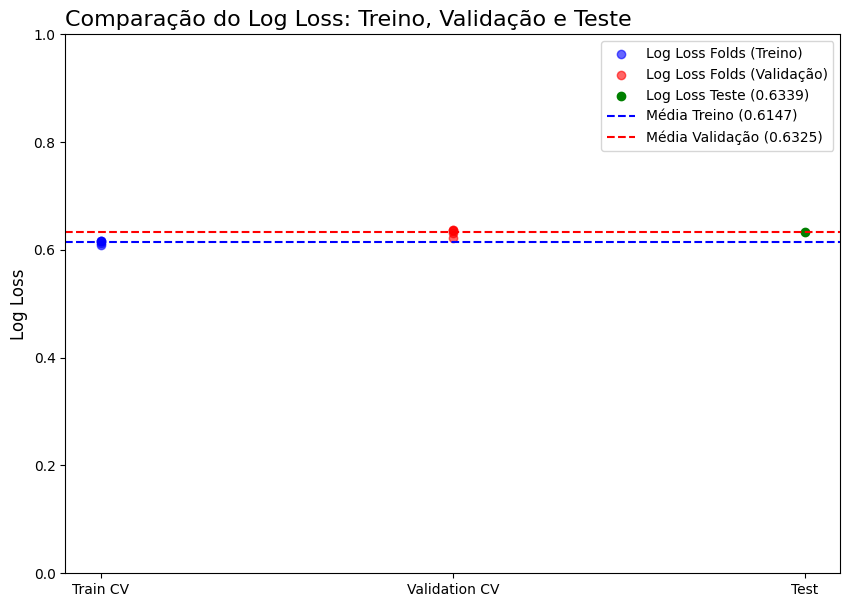

In [24]:
plt.figure(figsize=(10, 7))

labels = ['Train CV', 'Validation CV', 'Test']
train_losses = results_lgb['train']['log_loss']
val_losses = results_lgb['validation']['log_loss']
test_loss = test_metrics_lgb['log_loss']

plt.scatter(y=train_losses, x=['Train CV']*N_SPLITS, color='blue', alpha=0.6, label='Log Loss Folds (Treino)')
plt.scatter(y=val_losses, x=['Validation CV']*N_SPLITS, color='red', alpha=0.6, label='Log Loss Folds (Validação)')
plt.scatter([2], [test_loss], color='green', label=f'Log Loss Teste ({test_loss:.4f})')

mean_train_loss = np.mean(train_losses)
mean_val_loss = np.mean(val_losses)

plt.axhline(y=mean_train_loss, color='blue', linestyle='--', label=f'Média Treino ({mean_train_loss:.4f})')
plt.axhline(y=mean_val_loss, color='red', linestyle='--', label=f'Média Validação ({mean_val_loss:.4f})')

plt.title('Comparação do Log Loss: Treino, Validação e Teste', fontsize=16, loc='left')
plt.ylabel('Log Loss', fontsize=12)

plt.xticks(range(len(labels)), labels)
plt.ylim(0, 1)
plt.legend()
plt.grid(False)
plt.show()

### Matriz de confusão

In [25]:
order_by_label = ['Não evadiu', 'Evadiu']

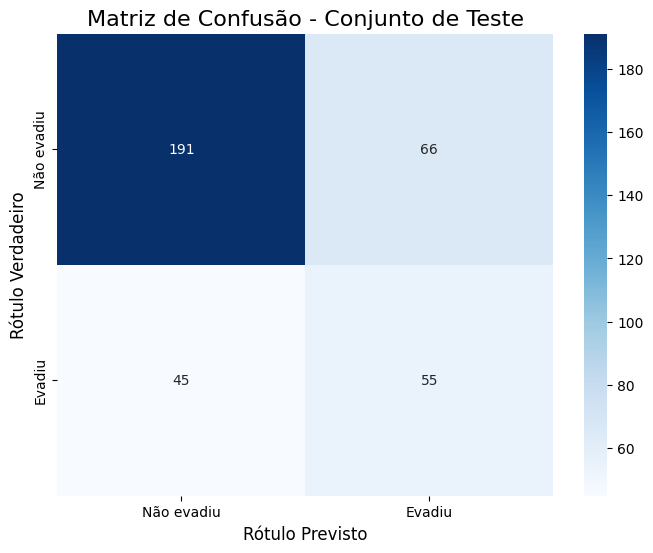

In [26]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(order_by_label), yticklabels=list(order_by_label))
plt.title('Matriz de Confusão - Conjunto de Teste', fontsize=16)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.show()

In [27]:
print(classification_report(y_test, y_pred, target_names=[str(c) for c in list(order_by_label)], digits=4))

              precision    recall  f1-score   support

  Não evadiu     0.8093    0.7432    0.7748       257
      Evadiu     0.4545    0.5500    0.4977       100

    accuracy                         0.6891       357
   macro avg     0.6319    0.6466    0.6363       357
weighted avg     0.7099    0.6891    0.6972       357



### Feature importance

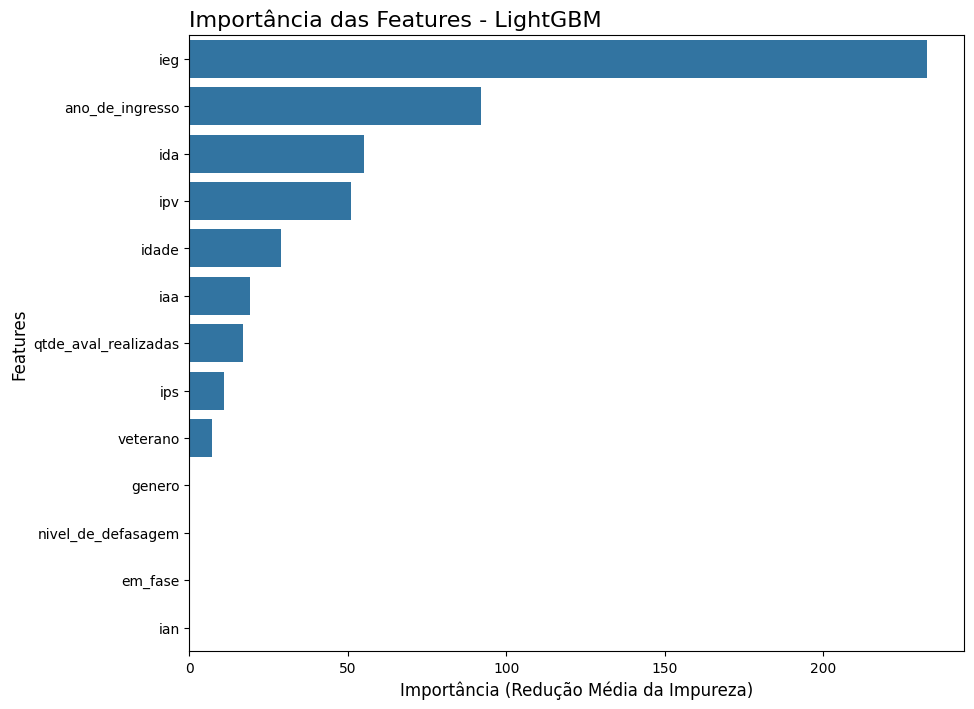

In [28]:
importances = lgbm_model.feature_importances_
feature_names = X_train.columns
feature_importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance_series, y=feature_importance_series.index)
plt.title('Importância das Features - LightGBM', fontsize=16, loc='left')
plt.xlabel('Importância (Redução Média da Impureza)', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.show()

### SHAP Values

In [29]:
explainer = shap.TreeExplainer(lgbm_model)

shap_explanation = explainer(X_test_scaled)

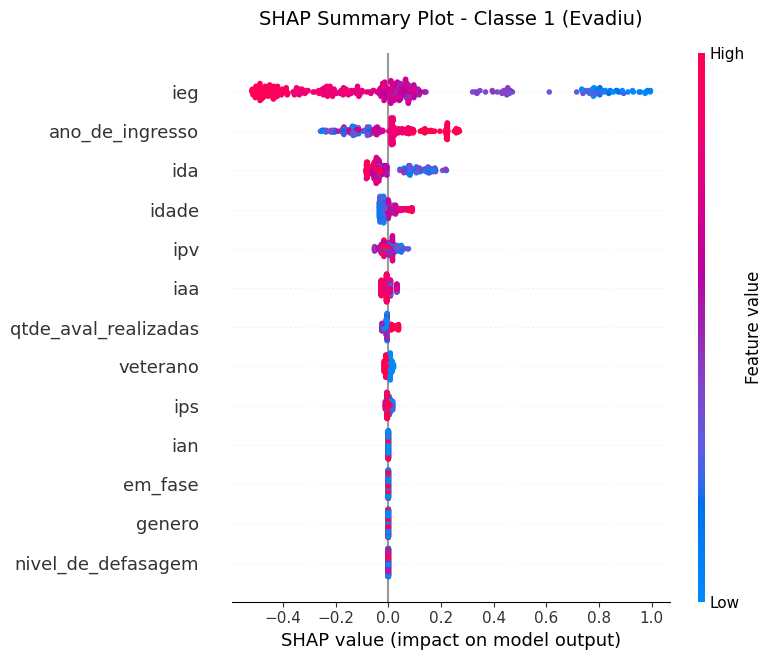

In [30]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_explanation,
    X_test_scaled,
    show=False
)
plt.title('SHAP Summary Plot - Classe 1 (Evadiu)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### Precision-Recall & ROC curves

/home/antonio/projetos/fase-5/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


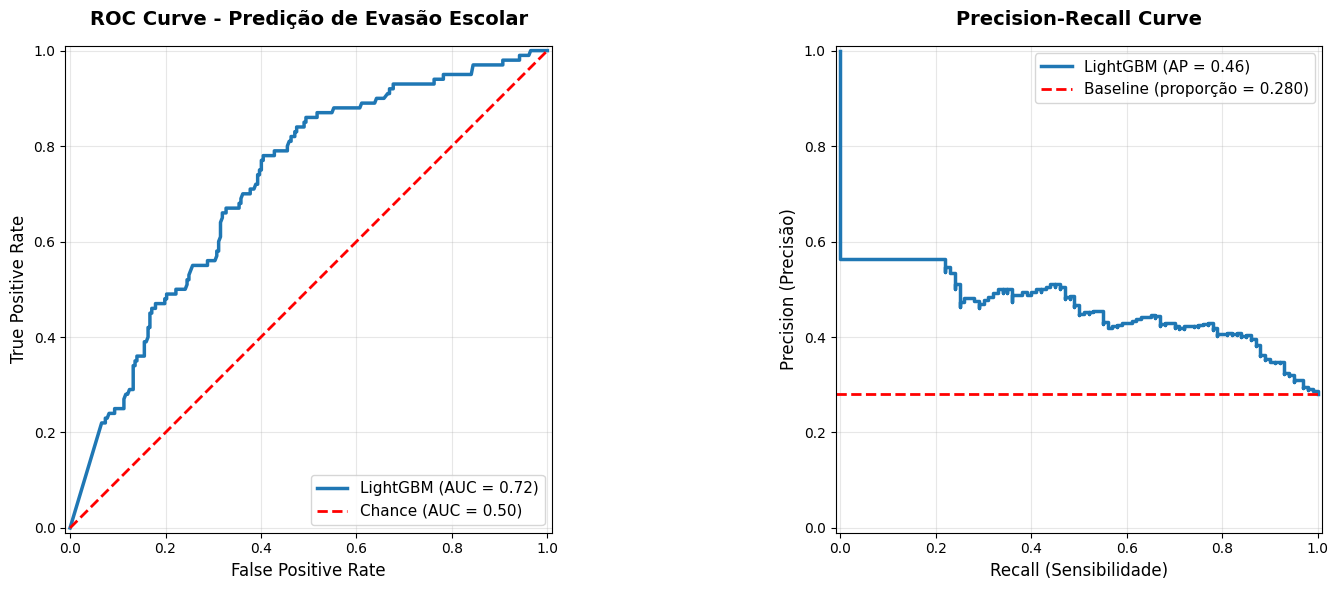

ROC-AUC: 0.7188
PR-AUC:  0.4633


In [35]:
# Obter probabilidades da classe positiva (1 = Evadiu)
y_proba = lgbm_model.predict_proba(X_test_scaled)[:, 1]

# Calcular curvas e métricas
fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=1)
prec, recall, _ = precision_recall_curve(y_test, y_proba, pos_label=1)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

# Baseline: proporção de evasões no conjunto de teste
baseline = y_test.sum() / len(y_test)

# Criar displays
roc_display = RocCurveDisplay(
    fpr=fpr, 
    tpr=tpr, 
    roc_auc=roc_auc,
    name='LightGBM'
)

pr_display = PrecisionRecallDisplay(
    precision=prec, 
    recall=recall,
    average_precision=pr_auc,
    name='LightGBM'
)

# Plotar curvas lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
roc_display.plot(ax=ax1, linewidth=2.5)
ax1.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Chance (AUC = 0.50)')
ax1.set_title('ROC Curve - Predição de Evasão Escolar', 
              fontsize=14, weight='bold', pad=15)
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(True, alpha=0.3)

# Precision-Recall Curve
pr_display.plot(ax=ax2, linewidth=2.5)
ax2.axhline(y=baseline, color='red', linestyle='--', linewidth=2,
            label=f'Baseline (proporção = {baseline:.3f})')
ax2.set_title('Precision-Recall Curve', 
              fontsize=14, weight='bold', pad=15)
ax2.set_xlabel('Recall (Sensibilidade)', fontsize=12)
ax2.set_ylabel('Precision (Precisão)', fontsize=12)
ax2.legend(loc='best', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Imprimir métricas principais
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")